In [17]:
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
import numpy as np
import torch
import torch.optim as optim
from variables import *
from ref import *
from read_complex_matrix import read_complex_matrix
from calculating_dynamic_resolution import *
torch.set_printoptions(precision=4)

import timeit

device = torch.device('cpu')

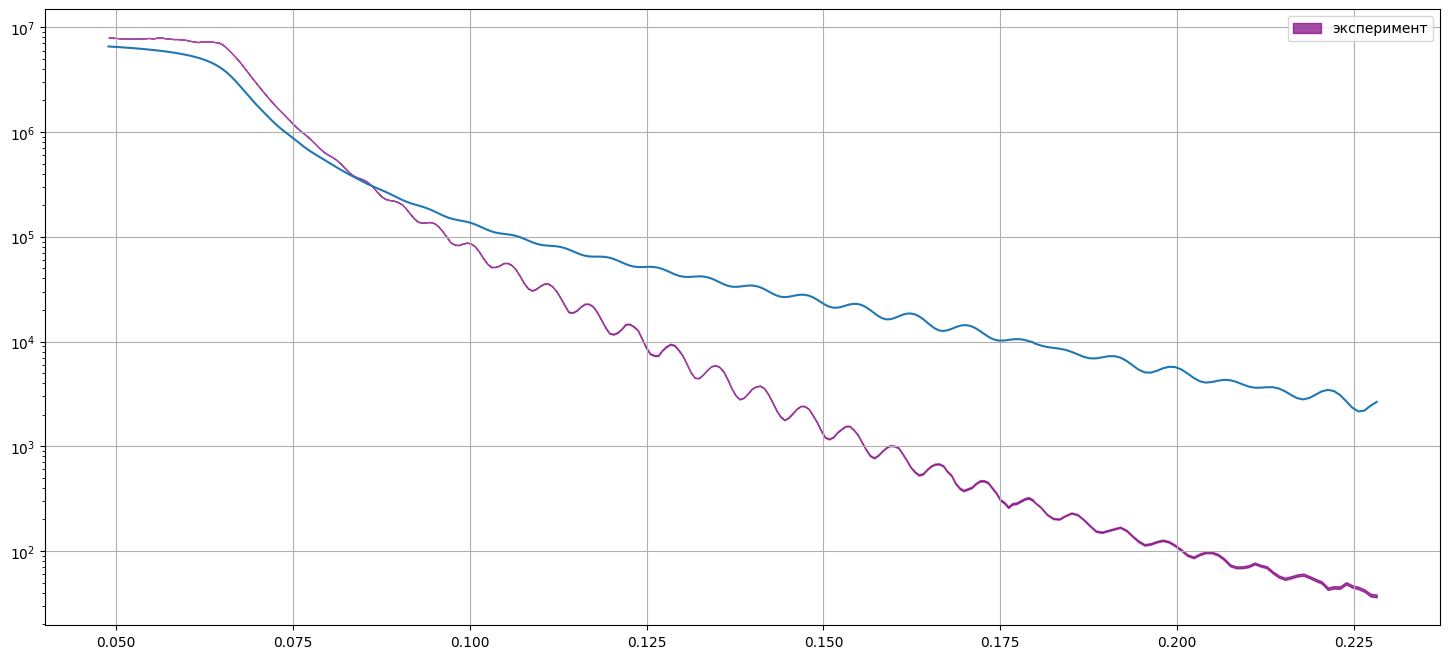

In [18]:
q = torch.pi*4.0e+10*torch.sin(torch.tensor(np.deg2rad(data[:, 0])))/1.524
r_mod, r_mod_conv= reflectometry(q, matr, 0.001*sigma, 0.001*sigma, I0, Ibkg)

fig, ax = plt.subplots(figsize=(18, 8))

ax.fill_between(q*1e-10, r1, r2, color='purple', alpha=0.7, label= 'эксперимент')
ax.plot(q.cpu().detach().numpy()[0:len(r_mod_conv.tolist())]*1e-10, (I0*r_mod_conv).tolist())
ax.set_yscale('log')

ax.legend()
plt.grid()
plt.show()

r = torch.tensor(r/I0.cpu().detach().numpy())

In [19]:
from add_roughness import *

fig = plot_density_profile(matr)
fig.show()


In [20]:
from objective_function import *

loss_function = Comparator(q, r)

objective_function = varbounds(all_bounds, loss_function.compare)
objective_function_weightless = varbounds(all_bounds, loss_function.compare_weightless)
objective_function_025 = varbounds(all_bounds, loss_function.compare_025)
objective_function_05 = varbounds(all_bounds, loss_function.compare_05)
objective_function_08 = varbounds(all_bounds, loss_function.compare_08)

In [21]:
objective_function_weightless.objective_function(initial_d, torch.complex(initial_r_rho, initial_i_rho), sigma1, sigma2, I0, Ibkg)

tensor(177987.1062, dtype=torch.float64, grad_fn=<SumBackward0>)

In [22]:
objective_function.objective_function(initial_d, torch.complex(initial_r_rho, initial_i_rho), sigma1, sigma2, I0, Ibkg)

tensor(2.4671, dtype=torch.float64, grad_fn=<SumBackward0>)

relative_loss:   1.0 



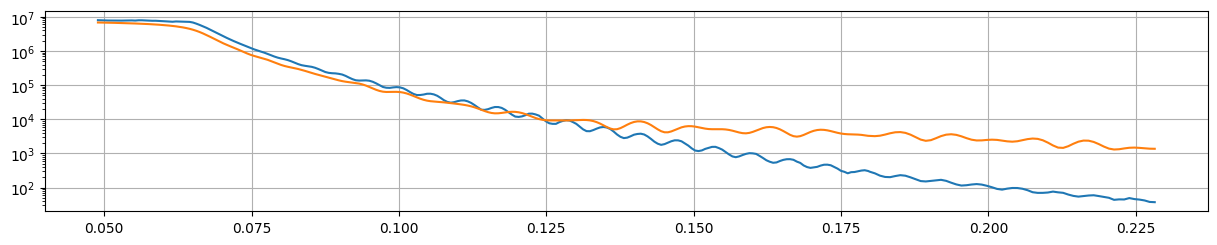

relative_loss:   0.3336450529843749 



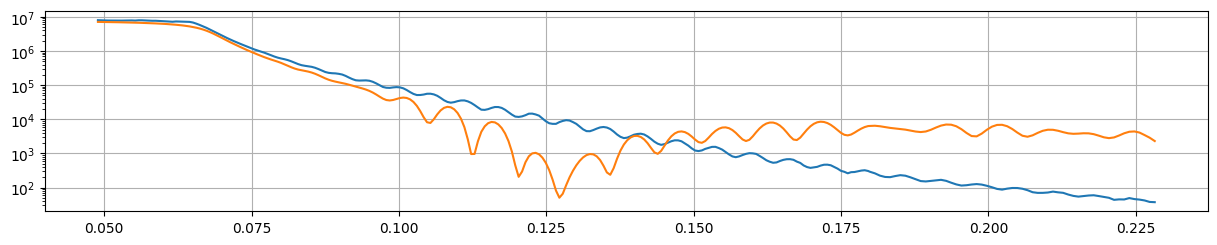

relative_loss:   0.33015810208627605 



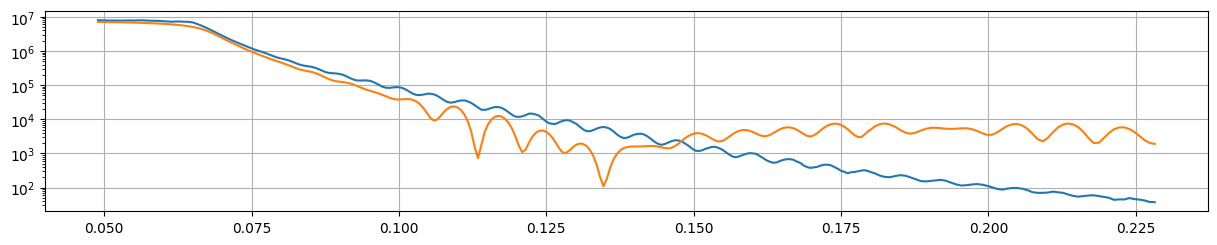

In [23]:
from optimizer import *
ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss, rel_losses1 = adamw(q, r, objective_function.objective_function, initial_sigma1, initial_sigma2,
                                                                      initial_d, initial_r_rho, initial_i_rho, I0, Ibkg,
                                                                      d_bounds, r_rho_bounds, i_rho_bounds, I_bounds, Ibkg_bounds,
                                                                      lr= 0.03, max_iter = 80, k=3)


relative_loss:   1.0 



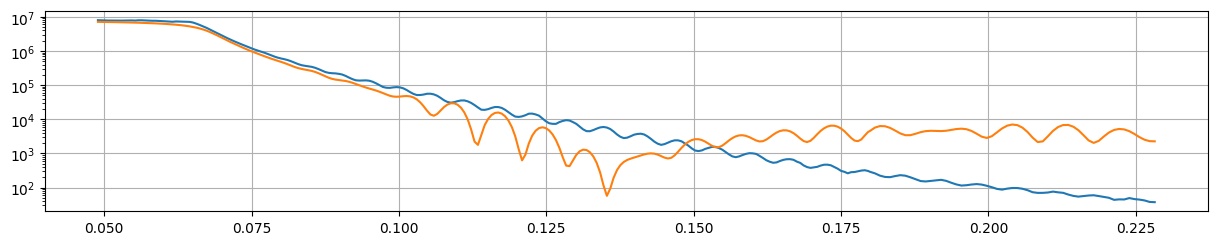

relative_loss:   0.06562659051897764 



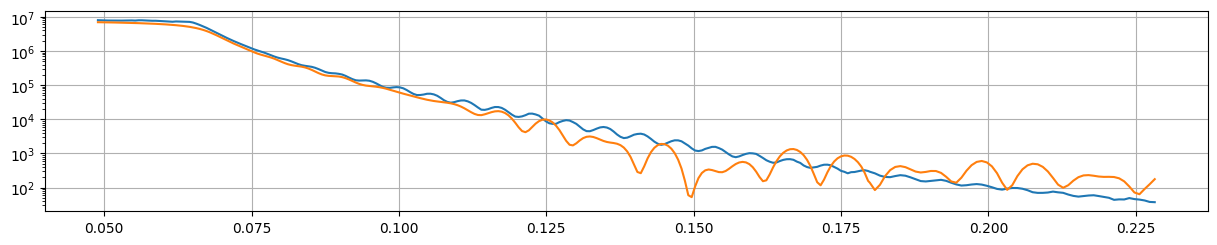

relative_loss:   0.057823177600606714 



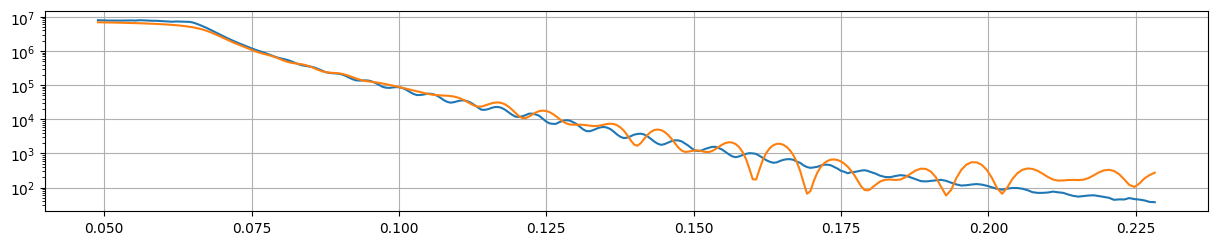

In [24]:
ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss, rel_losses2 = adamw(q, r, objective_function_08.objective_function,
                                                                        initial_sigma1, initial_sigma2,
                                                                        ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg,
                                                                        d_bounds, r_rho_bounds, i_rho_bounds, I_bounds,
                                                                        Ibkg_bounds,
                                                                        lr=0.02, max_iter=160, k=3)

relative_loss:   1.0 



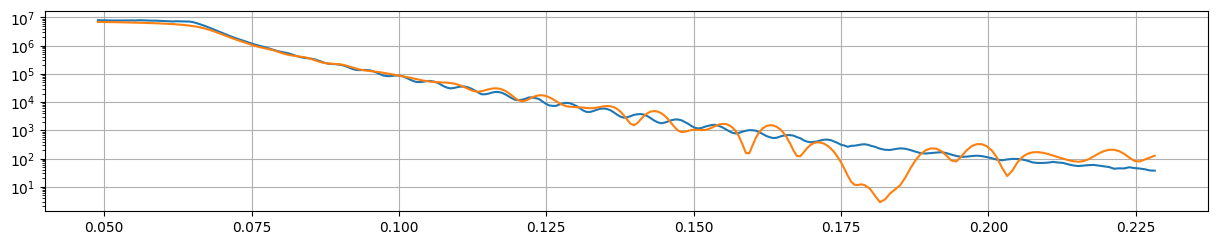

In [ ]:
ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss, rel_losses3 = adamw(q, r, objective_function_05.objective_function,
                                                                        initial_sigma1, initial_sigma2,
                                                                        ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg,
                                                                        d_bounds, r_rho_bounds, i_rho_bounds, I_bounds,
                                                                        Ibkg_bounds,
                                                                        lr=0.018, max_iter=100, k=2)

In [10]:
objective_function_sigma = varsigma(ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss_function.compare, all_bounds)

from scipy.optimize import differential_evolution as de

bounds = [sigma_bounds1,
          sigma_bounds2]

ans_sigma1, ans_sigma2 = de(
    func=objective_function_sigma.objective_function,
    bounds=bounds
).x

relative_loss:   1.0 



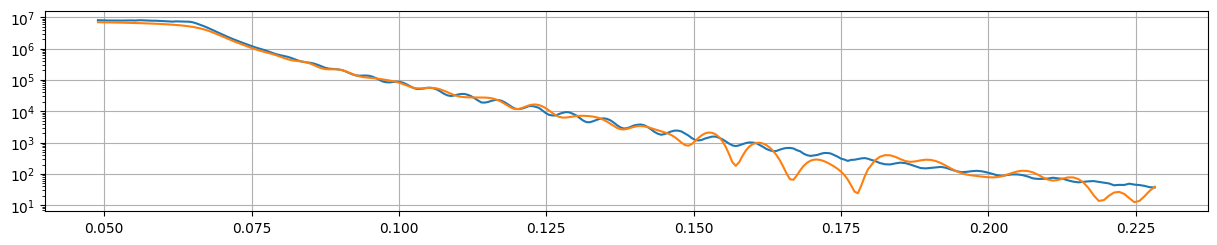

relative_loss:   0.8829608691269978 



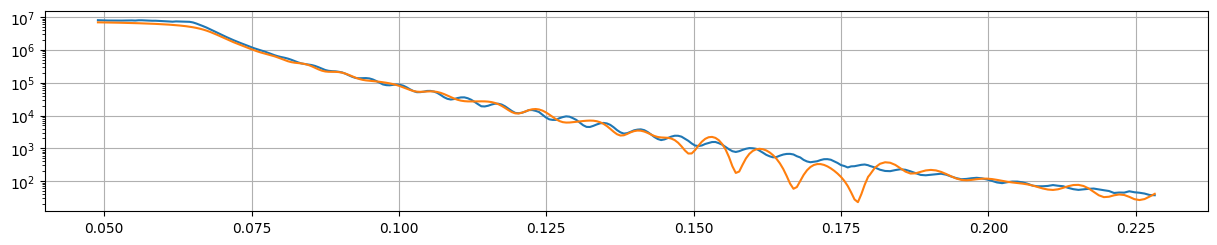

relative_loss:   0.8787294567890185 



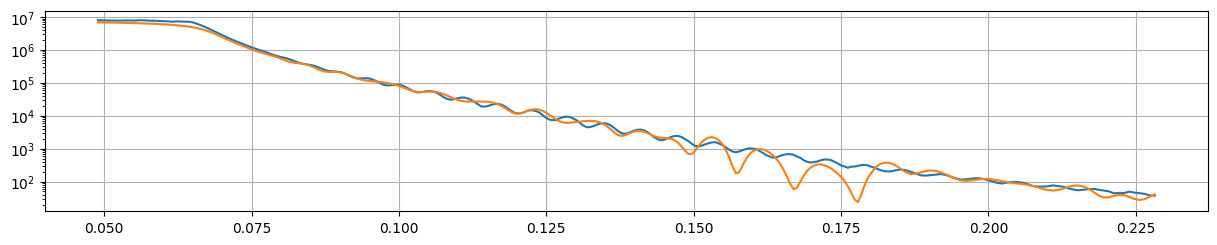

In [11]:
ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss, rel_losses4 = adamw(q, r, objective_function_025.objective_function,
                                                                      ans_sigma1, ans_sigma2,
                                                                      ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg,
                                                                      d_bounds, r_rho_bounds, i_rho_bounds, I_bounds, Ibkg_bounds,
                                                                      lr= 0.0012, max_iter = 290, k=3)

relative_loss:   1.0 



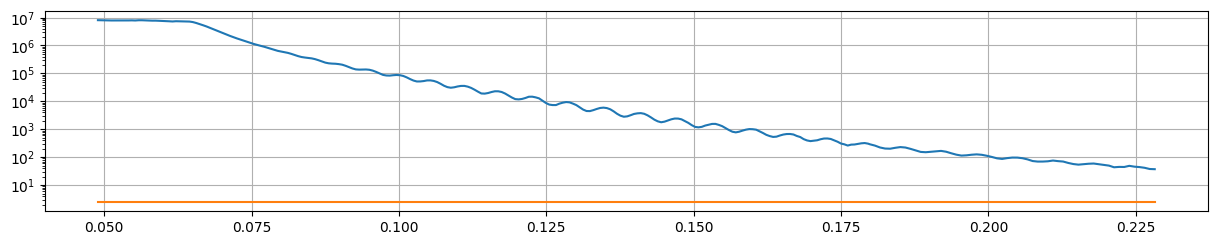

Converged at iteration 50


In [12]:
objective_function_weightless_sigma = varsigma(ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss_function.compare_weightless, all_bounds)
ans_sigma1, ans_sigma2 = de(
    func=objective_function_weightless_sigma.objective_function,
    bounds=bounds,
).x

ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss, rel_losses5 = adamw(q, r, objective_function_weightless.objective_function,
                                                                      ans_sigma1, ans_sigma2,
                                                                      ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg,
                                                                      d_bounds, r_rho_bounds, i_rho_bounds, I_bounds, Ibkg_bounds,
                                                                      lr= 0.01, max_iter = 358, k=4)

In [13]:
rel_losses2 = list(map(lambda x: x * rel_losses1[-1],  rel_losses2))
rel_losses3 = list(map(lambda x: x * rel_losses2[-1],  rel_losses3))
rel_losses4 = list(map(lambda x: x * rel_losses3[-1],  rel_losses4))
rel_losses5 = list(map(lambda x: x * rel_losses4[-1],  rel_losses5))
rel_losses = rel_losses1 + rel_losses2 + rel_losses3

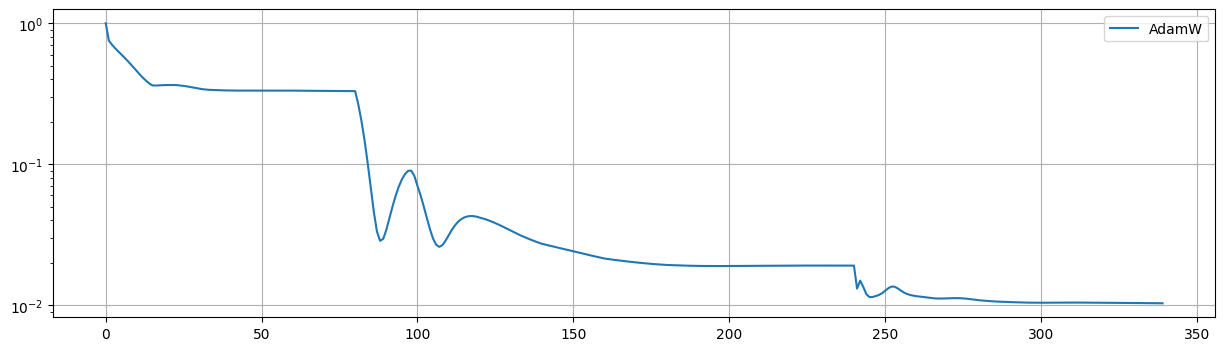

In [14]:
fig, ax = plt.subplots(figsize =(15, 4))

ax.plot(range(0,len(rel_losses)), rel_losses, label='AdamW')

ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()

In [15]:
ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss

(tensor([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]),
 tensor([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]),
 tensor([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]),
 tensor(7802934.7082, dtype=torch.float64),
 tensor(3.3000, dtype=torch.float64),
 279.74016958030927)

In [16]:
ans_sigma1, ans_sigma2

(np.float64(0.010641805611271989), np.float64(0.010999535892258695))